<a href="https://colab.research.google.com/github/mandalsathwik/Deepfake_Model/blob/main/titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#all the imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix # to test how the model is working

import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("/kaggle/input/test-file/tested.csv")
data.info() # to cheeck which data we are working
print(data.isnull().sum()) # to check missing values and to clean the values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [ ]:
#data cleaning
def preprocess_data(df):
  # Drop identifier columns and 'Cabin' as they are not useful for the model
  df.drop(columns=['PassengerId','Name','Ticket','Cabin','Embarked'], inplace=True)
  # Convert gender to numerical representation
  df["Sex"] = df["Sex"].map({"male":1,"female":0})
  # Create family and IsAlone features (these can be done before split as they don't rely on dataset-wide aggregations)
  df["Family"] = df["SibSp"] + df["Parch"]
  df["IsAlone"] = np.where(df["Family"] == 0, 1, 0)
  return df

In [ ]:
#fill in missing ages
def fill_missing_age(df):
  age_fill_map ={}
  for pclass in df["Pclass"].unique():
    if pclass not in age_fill_map:
      age_fill_map[pclass]= df[df["Pclass"]==pclass]["Age"].median()
  df["Age"]= df.apply(lambda row:age_fill_map[row["Pclass"]]if pd.isnull(row["Age"])else row["Age"],axis=1)


In [ ]:
#target varable so we can check who died and who survied
data = pd.read_csv("/kaggle/input/test-file/tested.csv") # Reload the original data
data = preprocess_data(data) # Apply initial preprocessing (drop columns, map Sex, create Family/IsAlone)

# Separate features (x) and target (y)
x = data.drop(columns=["Survived"])
y = data["Survived"]

# Split data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.25, random_state=42)


# 1. Fill missing 'Age' values based on 'Pclass' medians from X_train only
age_fill_map_train = X_train.groupby("Pclass")["Age"].median()
X_train["Age"] = X_train.apply(lambda row: age_fill_map_train[row["Pclass"]] if pd.isnull(row["Age"]) else row["Age"], axis=1)
X_test["Age"] = X_test.apply(lambda row: age_fill_map_train[row["Pclass"]] if pd.isnull(row["Age"]) else row["Age"], axis=1)

# 2. Fill missing 'Fare' values with the median from X_train only
fare_median_train = X_train['Fare'].median()
X_train['Fare'] = X_train['Fare'].fillna(fare_median_train)
X_test['Fare'] = X_test['Fare'].fillna(fare_median_train) # Use median from training set for test set

# 3. Create 'fareBin' feature by determining quantiles from X_train and applying to both
# pd.qcut returns quantiles, but pd.cut is used with explicit bins for consistent application
_, bins = pd.qcut(X_train["Fare"], 4, labels=False, retbins=True)

bins[0] = -np.inf
bins[-1] = np.inf
X_train["fareBin"] = pd.cut(X_train["Fare"], bins=bins, labels=False, include_lowest=True)
X_test["fareBin"] = pd.cut(X_test["Fare"], bins=bins, labels=False, include_lowest=True)

# 4. Create 'AgeBin'
age_bins = [0, 12, 20, 40, 60, np.inf]
X_train["AgeBin"] = pd.cut(X_train["Age"], bins=age_bins, labels=False, include_lowest=True)
X_test["AgeBin"] = pd.cut(X_test["Age"], bins=age_bins, labels=False, include_lowest=True)

In [ ]:
# now ml preprocing
scaler =MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



In [ ]:
#we are try to get best model -knn
def tune_model(X_train,Y_train):
  param_grid = {
      "n_neighbors":range(1,21),
      "metric":["euclidean","manhattan","minkowski"],
      "weights":["uniform","distance"]
  }

  model= KNeighborsClassifier()
  grid_search =GridSearchCV(model,param_grid,cv=5,n_jobs=-1,)
  grid_search.fit(X_train, Y_train) # Fit GridSearchCV to find the best estimator
  return grid_search.best_estimator_

In [ ]:
best_model = tune_model(X_train,Y_train)

Accuracy: 100.00%
Confusion Matrix :
[[69  0]
 [ 0 36]]


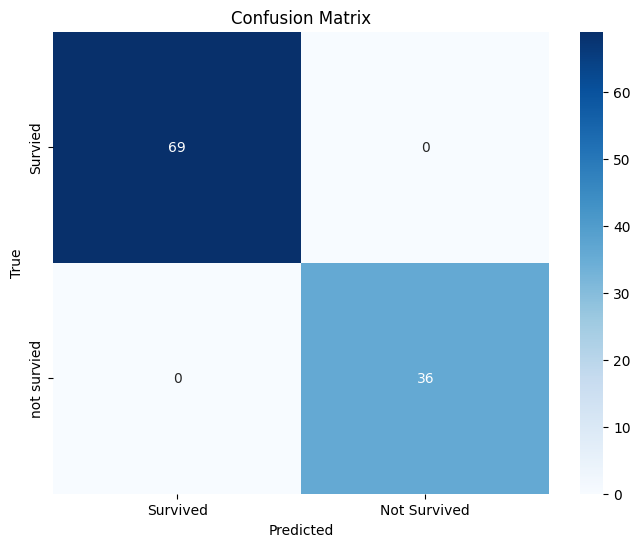

In [ ]:
def evaluate_model(model,X_test,Y_test):
  prediction = model.predict(X_test)
  accuracy = accuracy_score(Y_test,prediction)
  matrix = confusion_matrix(Y_test,prediction)
  return accuracy,matrix

accuracy, matrix = evaluate_model(best_model, X_test, Y_test)
print(f"Accuracy: {accuracy*100:.2f}%")
print(f'Confusion Matrix :')
print(matrix)
def plot_model(matrix):
  plt.figure(figsize=(8,6))
  sns.heatmap(matrix,annot=True,fmt='d',cmap='Blues',xticklabels=['Survived','Not Survived'],yticklabels=['Survied','not survied'])
  plt.xlabel('Predicted')
  plt.ylabel('True')
  plt.title('Confusion Matrix')
  plt.show()

plot_model(matrix)